# 제품 이상여부 판별 프로젝트


## 데이터 불러오기


### 필수 라이브러리


In [1]:
import os
from pprint import pprint

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import random
import torch
import warnings
warnings.filterwarnings("ignore")

### 데이터 읽어오기


In [2]:
ROOT_DIR = "data"
RANDOM_STATE = 736665
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(RANDOM_STATE)

seed_everything(RANDOM_STATE) 
# Load data
train_data = pd.read_csv(os.path.join(ROOT_DIR, "train.csv"))
test_data = pd.read_csv(os.path.join(ROOT_DIR, "test.csv"))

In [3]:
# test_data에는 target 컬럼이 있지만 다 결측치
# test_data에 Set ID가 있어서 열 하나가 train_data보다 많음
train_data.shape, test_data.shape

((40506, 464), (17361, 465))

## 데이터 전처리

### 중복 컬럼 제거

In [4]:
def delete_overlap_col(df):
    # 1. 칼럼 접두사에 따라 칼럼 그룹화 및 통합
    target_prefixes = ['Model.Suffix', 'Workorder', 'Wip Line', 'Insp. Seq No.', 'Insp Judge Code']
    prefix_dict = {}

    for col in df.columns:
        prefix = col.split('_')[0]  # '_' 앞의 텍스트 추출
        if prefix in target_prefixes:
            if prefix in prefix_dict:
                prefix_dict[prefix].append(col)
            else:
                prefix_dict[prefix] = [col]
    
    base_col = df.columns
    for prefix, cols in prefix_dict.items():
        if all(df[cols[0]].equals(df[col]) for col in cols):
            df[prefix] = df[cols[0]]
            print(prefix)
            df.drop(columns=cols, inplace=True)
    create_col = list(set(df.columns) - set(base_col))
    dif_col = list(set(base_col) - set(df.columns))
    print('중복 열 제거 진행')
    print(f'생성된 컬럼 : {create_col}')
    print(f'drop한 컬럼 : {dif_col}')
    print(f'drop한 컬럼 개수 : {len(dif_col)}개')

    return df

train_data = delete_overlap_col(train_data)
test_data = delete_overlap_col(test_data)

print((train_data.columns == test_data.columns[1:]).sum())
train_data.shape, test_data.shape

Wip Line
Model.Suffix
Workorder
Insp. Seq No.
Insp Judge Code
중복 열 제거 진행
생성된 컬럼 : ['Wip Line', 'Insp. Seq No.', 'Insp Judge Code', 'Workorder', 'Model.Suffix']
drop한 컬럼 : ['Wip Line_Fill2', 'Insp. Seq No._AutoClave', 'Model.Suffix_AutoClave', 'Wip Line_Fill1', 'Workorder_Fill1', 'Model.Suffix_Dam', 'Insp Judge Code_Fill2', 'Insp Judge Code_Dam', 'Insp Judge Code_AutoClave', 'Workorder_AutoClave', 'Model.Suffix_Fill1', 'Insp. Seq No._Dam', 'Wip Line_AutoClave', 'Insp. Seq No._Fill2', 'Insp. Seq No._Fill1', 'Model.Suffix_Fill2', 'Insp Judge Code_Fill1', 'Workorder_Dam', 'Workorder_Fill2', 'Wip Line_Dam']
drop한 컬럼 개수 : 20개
Wip Line
Model.Suffix
Workorder
Insp. Seq No.
Insp Judge Code
중복 열 제거 진행
생성된 컬럼 : ['Wip Line', 'Insp. Seq No.', 'Insp Judge Code', 'Workorder', 'Model.Suffix']
drop한 컬럼 : ['Wip Line_Fill2', 'Insp. Seq No._AutoClave', 'Model.Suffix_AutoClave', 'Wip Line_Fill1', 'Workorder_Fill1', 'Model.Suffix_Dam', 'Insp Judge Code_Fill2', 'Insp Judge Code_Dam', 'Insp Judge Code_AutoCla

((40506, 449), (17361, 450))

### 전체 행이 결측치이거나 똑같은 값인 칼럼 삭제

In [5]:
import pandas as pd

def drop_columns(df):
    
    drop_cols = []
    # 전체 행이 결측치인 칼럼 삭제
    base_col = df.columns
    df.dropna(axis=1, how='all', inplace=True)
    # drop된 컬럼 확인
    dif_col = list(set(base_col) - set(df.columns))
    drop_cols.extend(dif_col)
    print('모든 값이 결측치인 열 제거 진행')
    print(f'drop한 컬럼 : {dif_col}')
    print(f'drop한 컬럼 개수 : {len(dif_col)}개')

    # 특정 컬럼의 값이 다 같은 경우 컬럼 제거
    base_col = df.columns
    for col in df.columns:
        if (df[col].nunique() == 1) and (df[col].isnull().sum() == 0):
            df.drop(columns=col, inplace=True)
    dif_col = list(set(base_col) - set(df.columns))
    drop_cols.extend(dif_col)
    print('모든 값이 같은 열 제거 진행')
    print(f'drop한 컬럼 : {dif_col}')
    print(f'drop한 컬럼 개수 : {len(dif_col)}개')


    return df, drop_cols

train_data, drop_cols = drop_columns(train_data)
test_data = test_data.drop(columns=drop_cols)
train_data.shape, test_data.shape

모든 값이 결측치인 열 제거 진행
drop한 컬럼 : ['Stage1 Circle3 Distance Speed Judge Value_Dam', 'HEAD Standby Position X Unit Time_Dam', 'Stage3 Line2 Distance Speed Unit Time_Dam', 'Stage3 Line1 Distance Speed Judge Value_Dam', 'CURE SPEED Judge Value_Fill2', 'Stage1 Circle2 Distance Speed Judge Value_Dam', 'HEAD NORMAL COORDINATE Z AXIS(Stage1) Unit Time_Fill1', 'Dispense Volume(Stage2) Judge Value_Fill1', 'Stage1 Line4 Distance Speed Judge Value_Dam', 'HEAD NORMAL COORDINATE X AXIS(Stage1) Unit Time_Dam', 'Head Purge Position X Judge Value_Dam', 'HEAD Standby Position X Unit Time_Fill2', 'GMES_ORIGIN_INSP_JUDGE_CODE Unit Time_AutoClave', 'Dispense Volume(Stage2) Unit Time_Fill1', 'DISCHARGED SPEED OF RESIN Judge Value_Fill2', 'DISCHARGED TIME OF RESIN(Stage2) Judge Value_Fill2', 'Head Zero Position Y Judge Value_Dam', 'HEAD NORMAL COORDINATE Y AXIS(Stage1) Judge Value_Fill2', 'HEAD Standby Position Z Unit Time_Dam', 'Dispense Volume(Stage3) Unit Time_Fill1', 'Dispense Volume(Stage2) Unit Time_Fill2

((40506, 145), (17361, 146))

### 'Judge Value' 칼럼의 결측치를 'NG'로 대체

In [6]:
ok_columns = [col for col in train_data.columns if train_data[col].astype(str).str.contains('OK').any()]
Judge_Value_col = []
for col in ok_columns:
    if 'Judge Value' in col:
        Judge_Value_col.append(col)

                
def missing_imputation(df, cols = None):
    df[col].fillna('NG', inplace=True)
    return df

train_data = missing_imputation(train_data, cols = Judge_Value_col)
test_data = missing_imputation(test_data, cols = Judge_Value_col)
train_data.shape, test_data.shape

((40506, 145), (17361, 146))

### target label 변경 

In [7]:
train_data.loc[train_data['target'] == 'Normal', 'target'] = 0
train_data.loc[train_data['target'] == 'AbNormal', 'target'] = 1
train_data['target'] = train_data['target'].astype(int)
train_data['target']

0        0
1        0
2        0
3        0
4        0
        ..
40501    0
40502    0
40503    0
40504    0
40505    1
Name: target, Length: 40506, dtype: int32

### 데이터 분할


In [8]:
df_train, df_val = train_test_split(
    train_data,
    test_size=0.3,
    stratify=train_data["target"],
    random_state=RANDOM_STATE,
)

In [9]:
def print_stats(df: pd.DataFrame):
    num_normal = len(df[df["target"] == 0])
    num_abnormal = len(df[df["target"] == 1])

    print(f"  Total: Normal: {num_normal}, AbNormal: {num_abnormal}" + f" ratio: {num_abnormal/(num_normal + num_abnormal)}")


# Print statistics
print(f"  \tAbnormal\tNormal")
print_stats(df_train)
print_stats(df_val)

  	Abnormal	Normal
  Total: Normal: 26709, AbNormal: 1645 ratio: 0.0580165056076744
  Total: Normal: 11447, AbNormal: 705 ratio: 0.05801514154048716


#### 컬럼 선택

- 필요한 컬럼 선택하세요~
- 아래 코드는 수치형 변수만 

In [81]:
features = []

for col in df_train.columns.drop('target'):
    try:
        df_train[col].astype(int)
        features.append(col)
    except:
        continue
len(features)

130

### 이상치 처리 - 오토인코더

In [79]:
df_train_ae = df_train.copy()
df_train_ae = df_train_ae[features]
df_train_ae_y = df_train["target"]

In [66]:
# df_val_ae = df_val.copy()
# df_val_ae = df_val_ae[features]
# df_val_ae_y = df_val["target"]

# df_val_ae = scaler.transform(df_val_ae)

In [80]:
# df_train_ae 스케일링 진행
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_train_ae = scaler.fit_transform(df_train_ae)

In [81]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 입력 차원
input_dim = df_train_ae.shape[1]

# 인코더
input_layer = layers.Input(shape=(input_dim,))
encoder = layers.Dense(64, activation="relu")(input_layer)
encoder = layers.Dense(32, activation="relu")(encoder)
latent_space = layers.Dense(16, activation="relu")(encoder)  # 잠재 공간 (저차원 표현)

# 디코더
decoder = layers.Dense(32, activation="relu")(latent_space)
decoder = layers.Dense(64, activation="relu")(decoder)
output_layer = layers.Dense(input_dim, activation="sigmoid")(decoder)  # 원래 차원으로 복원

# 오토인코더 모델
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# 모델 컴파일
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# 모델 요약 출력
autoencoder.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 130)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │         8,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 130)            │         8,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,098 (86.32 KB)

 Trainable params: 22,098 (86.32 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
from tensorflow.keras.callbacks import EarlyStopping

# 얼리 스토핑 콜백 설정
early_stopping = EarlyStopping(
    monitor='val_loss',  # 모니터링할 지표 ('val_loss' 또는 'val_accuracy' 등)
    patience=5,          # 개선이 없을 때 기다릴 에포크 수
    restore_best_weights=True  # 가장 낮은 val_loss를 기록한 모델 가중치를 복원
)

# 모델 훈련
history = autoencoder.fit(
    df_train_ae, df_train_ae,
    epochs=100,                # 최대 에포크 수
    batch_size=32,
    shuffle=True,
    validation_split=0.2,      # 검증 데이터 비율
    callbacks=[early_stopping] # 얼리 스토핑 콜백 추가
)


Epoch 1/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.7533 - val_loss: 0.6138
Epoch 2/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6070 - val_loss: 0.6097
Epoch 3/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5981 - val_loss: 0.6049
Epoch 4/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6077 - val_loss: 0.5944
Epoch 5/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5859 - val_loss: 0.5939
Epoch 6/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5883 - val_loss: 0.5920
Epoch 7/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5890 - val_loss: 0.5905
Epoch 8/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5867 - val_loss: 0.5902
Epoch 9/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5875 - val_loss: 0.5890
Epoch 10/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5803 - val_loss: 0.5888
Epoch 11/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5782 - val_loss: 0.5835
Epoch 12/100
709/709 ━━━━━━━━━━━━━━━━━━━━

In [83]:
# 복원된 데이터
X_pred = autoencoder.predict(df_train_ae)
threshold = 0.01
reconstruction_error = np.mean(np.square(df_train_ae - X_pred), axis=1)
reconstruction_error

887/887 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([0.58119521, 0.51659741, 0.449871  , ..., 0.64652865, 0.54220335,
       0.55330224])

In [86]:
df_train_ae = df_train.copy()
df_train_ae['err'] = reconstruction_error

In [87]:
df_train_ae.groupby('target')['err'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,26709.0,0.555759,0.555263,0.191617,0.333957,0.529905,0.591638,9.051776
1,1645.0,0.677901,3.581058,0.206937,0.363050,0.543070,0.613626,144.374304


<Axes: ylabel='err'>

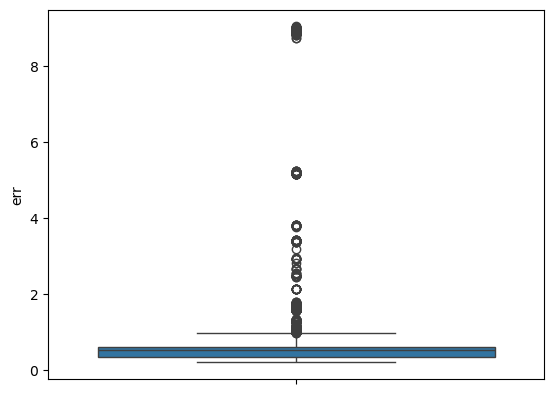

In [94]:
sns.boxplot(df_train_ae[df_train_ae["target"] == 0]["err"])

<Axes: ylabel='err'>

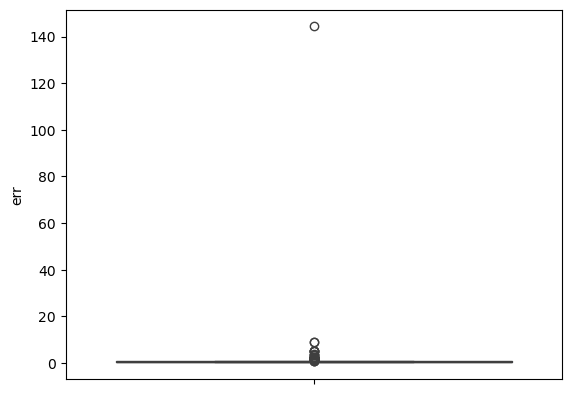

In [126]:
sns.boxplot(df_train_ae[df_train_ae["target"] == 1]["err"])

In [99]:
temp[temp['err']> 100]

,Equipment_Dam,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam,CURE END POSITION Θ Collect Result_Dam,CURE SPEED Collect Result_Dam,CURE START POSITION X Collect Result_Dam,CURE START POSITION Θ Collect Result_Dam,DISCHARGED SPEED OF RESIN Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam,...,Head Purge Position Z Collect Result_Fill2,Machine Tact time Collect Result_Fill2,PalletID Collect Result_Fill2,Production Qty Collect Result_Fill2,Receip No Collect Result_Fill2,WorkMode Collect Result_Fill2,target,Model.Suffix,Workorder,err
37520,Dam dispenser #2,1000.0,12.5,90,70,280,90,16,13.2,6.5,...,50,85.0,20.1,8,181,1,1,AJX75334501,3M1XC484-1,144.374304


<Axes: ylabel='err'>

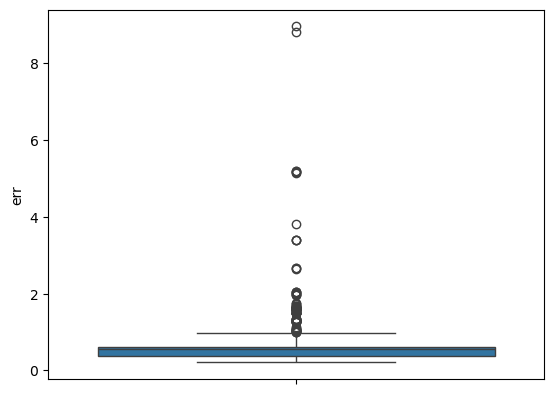

In [98]:
sns.boxplot(temp[temp['err']< 100]["err"])

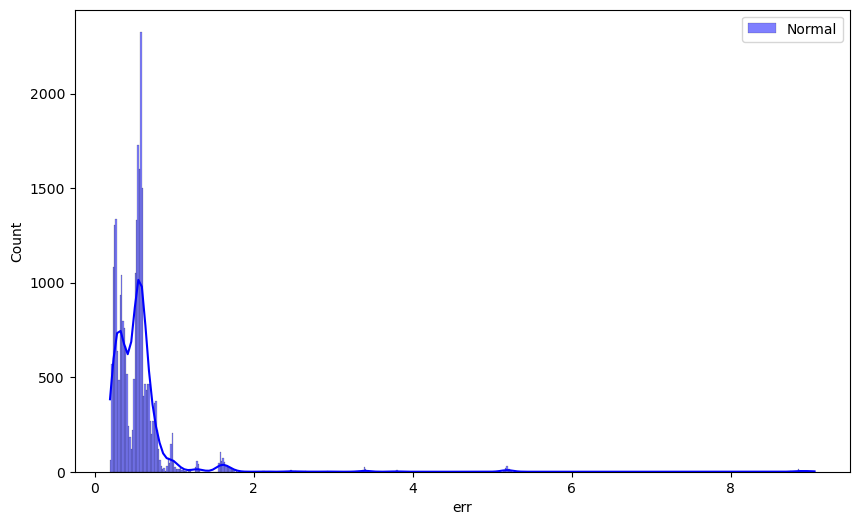

In [90]:
# df_train_ae의 target값에 따른 err 분포를 각각 따로 그리기
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df_train_ae[df_train_ae["target"] == 0]["err"], color="blue", label="Normal", kde=True)

plt.legend()
plt.show()



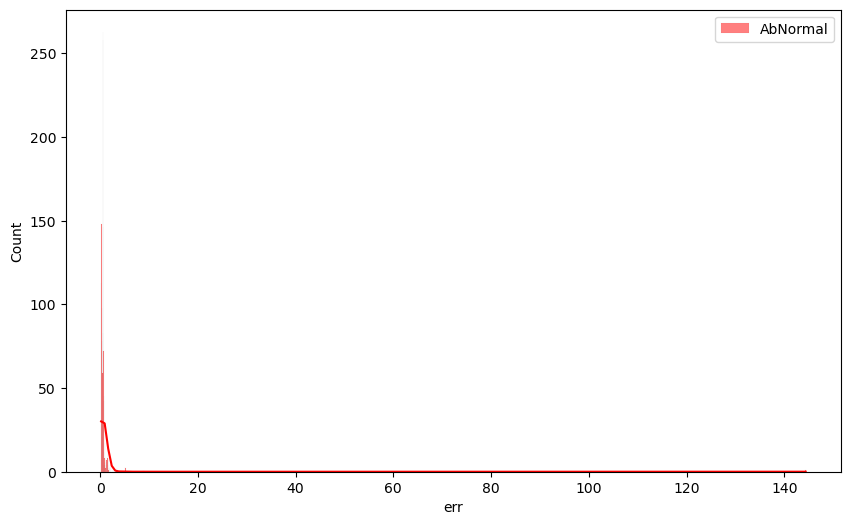

In [89]:

plt.figure(figsize=(10, 6))
sns.histplot(df_train_ae[df_train_ae["target"] == 1]["err"], color="red", label="AbNormal", kde=True)

plt.legend()
plt.show()

### 데이터 불균형 문제 -> 샘플링

In [11]:
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from collections import Counter

# 예제 데이터 생성

# 원본 데이터 클래스 비율
print_stats(df_train)

X, y = df_train.drop(columns=["target"]), df_train["target"]
X = X[features]

# Random Oversampling
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_ros, y_ros = ros.fit_resample(X, y)
print("Random Oversampling 클래스 비율:", Counter(y_ros))

# SMOTETomek
smote = SMOTE(random_state=RANDOM_STATE)
X_smote, y_smote = smote.fit_resample(X, y)
print("SMOTE 클래스 비율:", Counter(y_smote))

# SMOTETomek
smote_tomek = SMOTETomek(random_state=RANDOM_STATE)
X_smote_tomek, y_smote_tomek = smote_tomek.fit_resample(X, y)
print("SMOTETomek 클래스 비율:", Counter(y_smote_tomek))

# SMOTEENN - 오래 걸림..
smote_enn = SMOTEENN(random_state=RANDOM_STATE)
X_smote_enn, y_smote_enn = smote_enn.fit_resample(X, y)
print("SMOTEENN 클래스 비율:", Counter(y_smote_enn))


  Total: Normal: 26709, AbNormal: 1645 ratio: 0.0580165056076744
Random Oversampling 클래스 비율: Counter({0: 26709, 1: 26709})
SMOTE 클래스 비율: Counter({0: 26709, 1: 26709})
SMOTETomek 클래스 비율: Counter({0: 25831, 1: 25831})
SMOTEENN 클래스 비율: Counter({1: 21875, 0: 16983})


### 언더샘플링

In [12]:
normal_ratio = 3.0
# 전체 데이터에서 Normal과 AbNormal 분리
df_normal = df_train[df_train["target"] == 0]
df_abnormal = df_train[df_train["target"] == 1]

num_normal = len(df_normal)
num_abnormal = len(df_abnormal)
print(f"  Total: Normal: {num_normal}, AbNormal: {num_abnormal}")

df_normal = df_normal.sample(n=int(num_abnormal * normal_ratio), replace=False, random_state=RANDOM_STATE)
df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
X_under, y_under = df_concat.drop(columns=["target"]), df_concat["target"]
# 컬럼 선택
X_under = X_under[features]
print("언더샘플링 후 클래스 비율:", Counter(y_under))

  Total: Normal: 26709, AbNormal: 1645
언더샘플링 후 클래스 비율: Counter({0: 4935, 1: 1645})


In [13]:
X_under

,CURE END POSITION X Collect Result_Dam,CURE END POSITION Z Collect Result_Dam,CURE END POSITION Θ Collect Result_Dam,CURE SPEED Collect Result_Dam,CURE START POSITION X Collect Result_Dam,CURE START POSITION Θ Collect Result_Dam,DISCHARGED SPEED OF RESIN Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam,DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam,...,Head Clean Position Y Collect Result_Fill2,Head Clean Position Z Collect Result_Fill2,Head Purge Position X Collect Result_Fill2,Head Purge Position Y Collect Result_Fill2,Head Purge Position Z Collect Result_Fill2,Machine Tact time Collect Result_Fill2,PalletID Collect Result_Fill2,Production Qty Collect Result_Fill2,Receip No Collect Result_Fill2,WorkMode Collect Result_Fill2
0,240.0,2.5,-90,100,1030,-90,16,14.9,8.4,14.7,...,119,50.0,91.8,270,50,114.612,19.9,4,94,1
1,240.0,2.5,-90,70,1030,-90,10,9.6,3.9,9.6,...,50,91.8,270.0,50,85,19.000,8.0,253,1,0
2,240.0,2.5,-90,70,1030,-90,10,9.6,4.9,9.7,...,50,91.8,270.0,50,85,19.900,1.0,188,1,0
3,1000.0,12.5,90,70,280,90,10,21.3,10.6,21.3,...,119,50.0,91.8,270,50,85.000,19.5,9,88,1
4,1000.0,12.5,90,70,280,90,10,21.3,8.4,21.3,...,50,91.8,270.0,50,85,19.900,14.0,90,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6575,240.0,2.5,-90,70,1030,-90,16,13.2,6.6,13.2,...,119,50.0,91.8,270,50,85.000,19.9,6,27,1
6576,1000.0,12.5,90,100,280,90,16,14.9,8.6,14.8,...,119,50.0,91.8,270,50,114.612,20.1,13,102,1
6577,1000.0,12.5,90,70,280,90,16,14.2,8.3,14.2,...,119,50.0,91.8,270,50,85.000,19.7,16,30,6
6578,1000.0,12.5,90,70,280,90,10,21.3,10.5,21.3,...,119,50.0,91.8,270,50,85.000,20.3,12,58,3


In [14]:
len(features)

130

## 모델 생성 및 학습

In [15]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cat

rf = RandomForestClassifier(random_state=RANDOM_STATE)
xgb = xgb.XGBClassifier(random_state=RANDOM_STATE)
lgbm = lgb.LGBMClassifier(random_state=RANDOM_STATE)
cat = cat.CatBoostClassifier(random_state=RANDOM_STATE)

In [16]:
val_x = df_val[features]
val_y = df_val["target"]
val_x.shape, val_y.shape, val_y.value_counts()

((12152, 130),
 (12152,),
 target
 0    11447
 1      705
 Name: count, dtype: int64)

In [17]:
result_df = pd.DataFrame(columns=["sampling", "model", "f1", "precision", "recall", "accuracy"])

for sample_tech in tqdm(["ros", "smote", "smote_tomek", "smote_enn", "under"]):
    train_x = globals()[f"X_{sample_tech}"]
    train_y = globals()[f"y_{sample_tech}"]
    for model in [rf, xgb, lgbm]:
        model.fit(train_x, train_y)
        y_pred = model.predict(val_x)
        f1 = f1_score(val_y, y_pred)
        precision = precision_score(val_y, y_pred)
        recall = recall_score(val_y, y_pred)
        accuracy = accuracy_score(val_y, y_pred)
        result_df.loc[len(result_df), :] = [sample_tech, model.__class__.__name__, f1, precision, recall, accuracy]
    del train_x, train_y
result_df

  0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 26709, number of negative: 26709
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015336 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3702
[LightGBM] [Info] Number of data points in the train set: 53418, number of used features: 130
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


 20%|██        | 1/5 [00:33<02:13, 33.27s/it]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 26709, number of negative: 26709
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043889 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16519
[LightGBM] [Info] Number of data points in the train set: 53418, number of used features: 130
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


 40%|████      | 2/5 [01:12<01:50, 36.69s/it]

...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 21875, number of negative: 16983
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023727 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16451
[LightGBM] [Info] Number of data points in the train set: 38858, number of used features: 130
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.562947 -> initscore=0.253132
[LightGBM] [Info] Start training from score 0.253132


 80%|████████  | 4/5 [02:16<00:33, 33.01s/it]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1645, number of negative: 4935
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008004 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3449
[LightGBM] [Info] Number of data points in the train set: 6580, number of used features: 130
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.250000 -> initscore=-1.098612
[LightGBM] [Info] Start training from score -1.098612


100%|██████████| 5/5 [02:24<00:00, 28.98s/it]


,sampling,model,f1,precision,recall,accuracy
0,ros,RandomForestClassifier,0.095839,0.431818,0.053901,0.940997
1,ros,XGBClassifier,0.16015,0.108951,0.302128,0.816162
2,ros,LGBMClassifier,0.179463,0.114657,0.412766,0.781024
3,smote,RandomForestClassifier,0.096324,0.452381,0.053901,0.941327
4,smote,XGBClassifier,0.09883,0.59375,0.053901,0.942972
5,smote,LGBMClassifier,0.074766,0.636364,0.039716,0.942972
6,smote_tomek,RandomForestClassifier,0.100629,0.444444,0.056738,0.941162
7,smote_tomek,XGBClassifier,0.095979,0.560606,0.052482,0.942643
8,smote_tomek,LGBMClassifier,0.074369,0.583333,0.039716,0.942643
9,smote_enn,RandomForestClassifier,0.131181,0.227273,0.092199,0.929147


### 테스트 데이터 예측


In [18]:
model = lgb.LGBMClassifier(random_state=RANDOM_STATE)
model.fit(X_ros, y_ros)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 26709, number of negative: 26709
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028536 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3702
[LightGBM] [Info] Number of data points in the train set: 53418, number of used features: 130
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(random_state=736665)

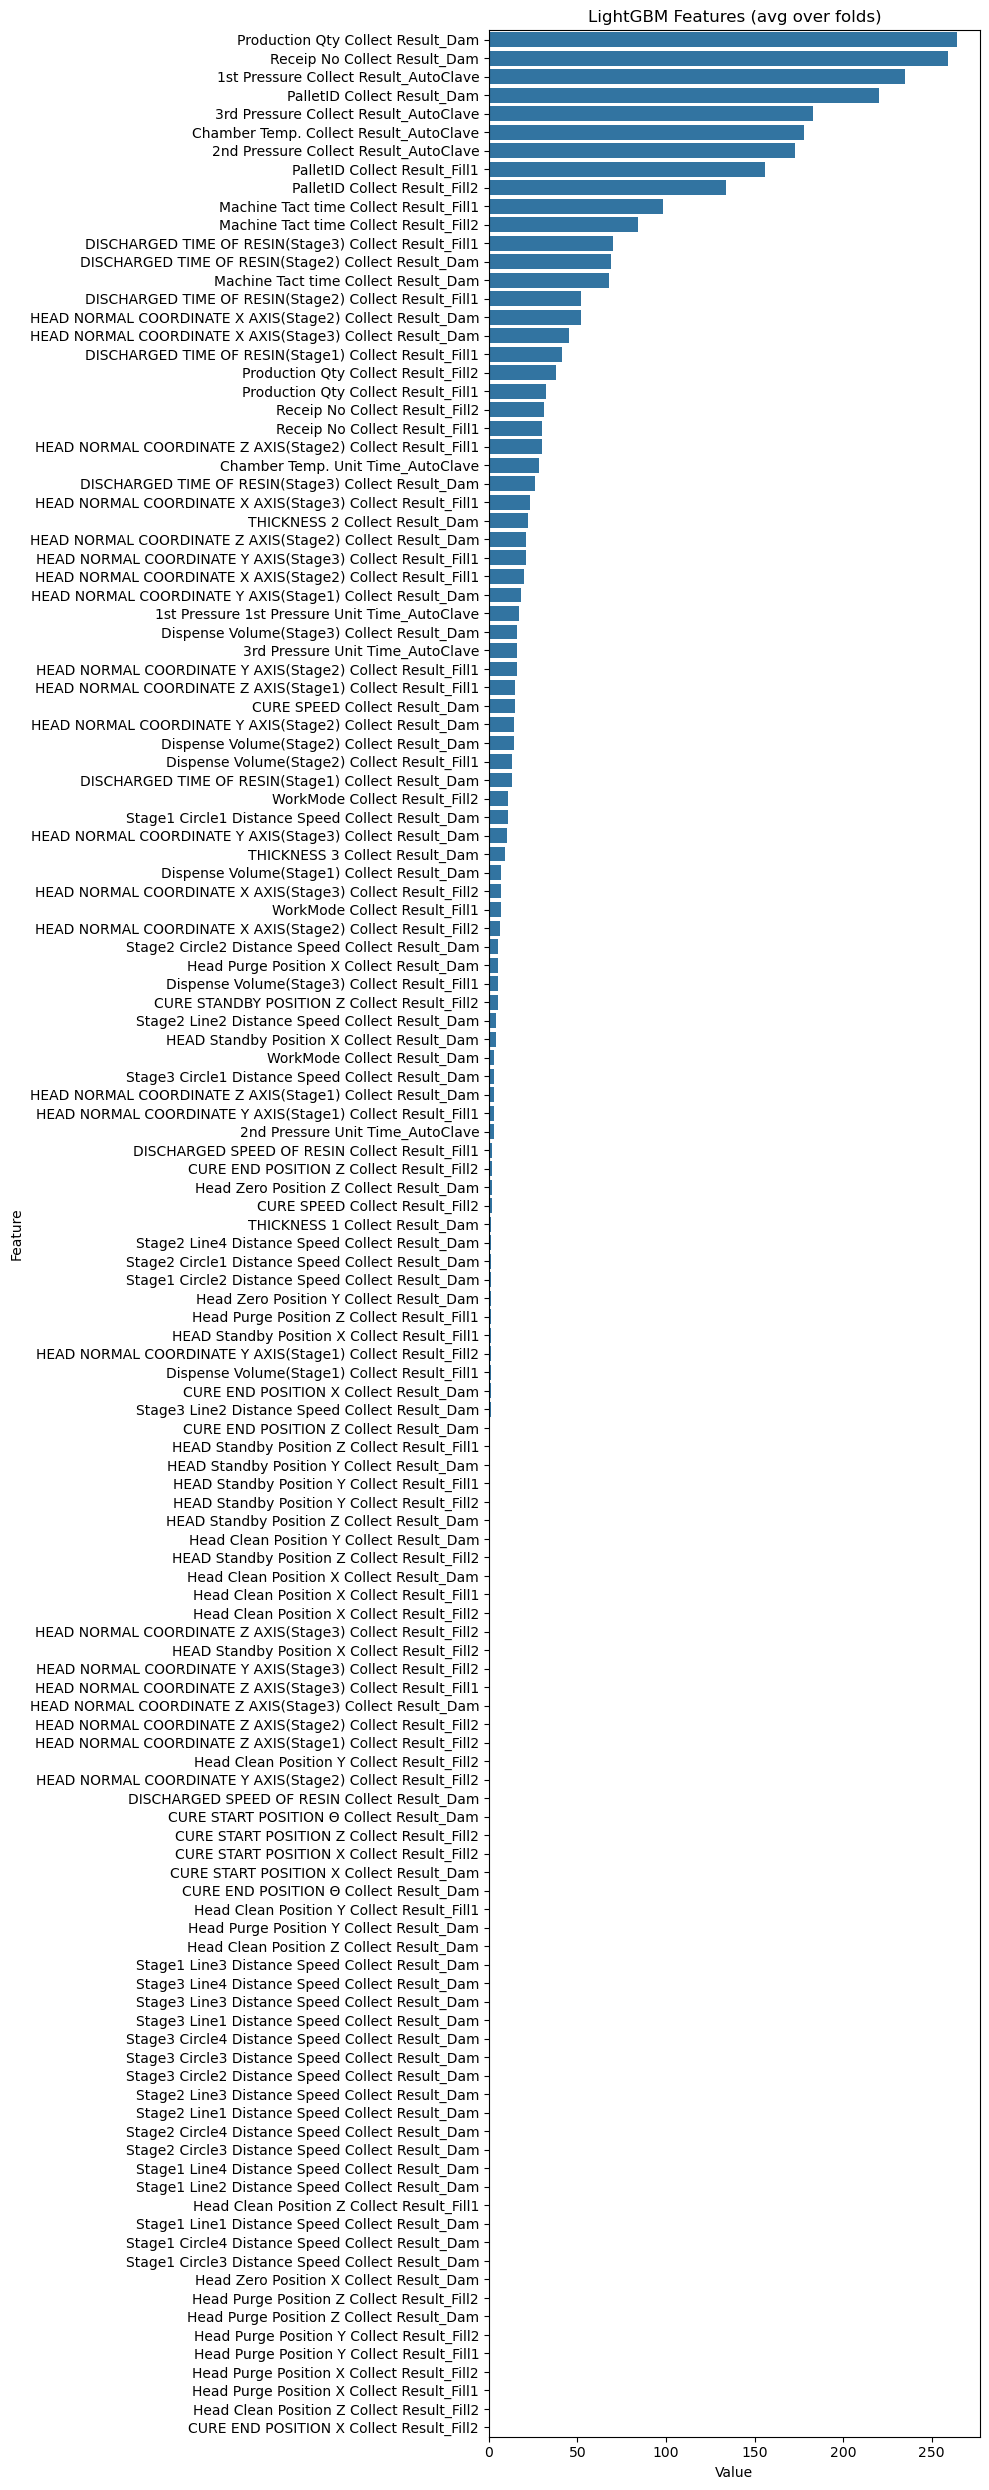

In [27]:
# feature importance 정렬 후  시각화
feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, features)), columns=['Value','Feature'])

plt.figure(figsize=(10, 25))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('LightGBM Features (avg over folds)')
plt.tight_layout()
plt.show()


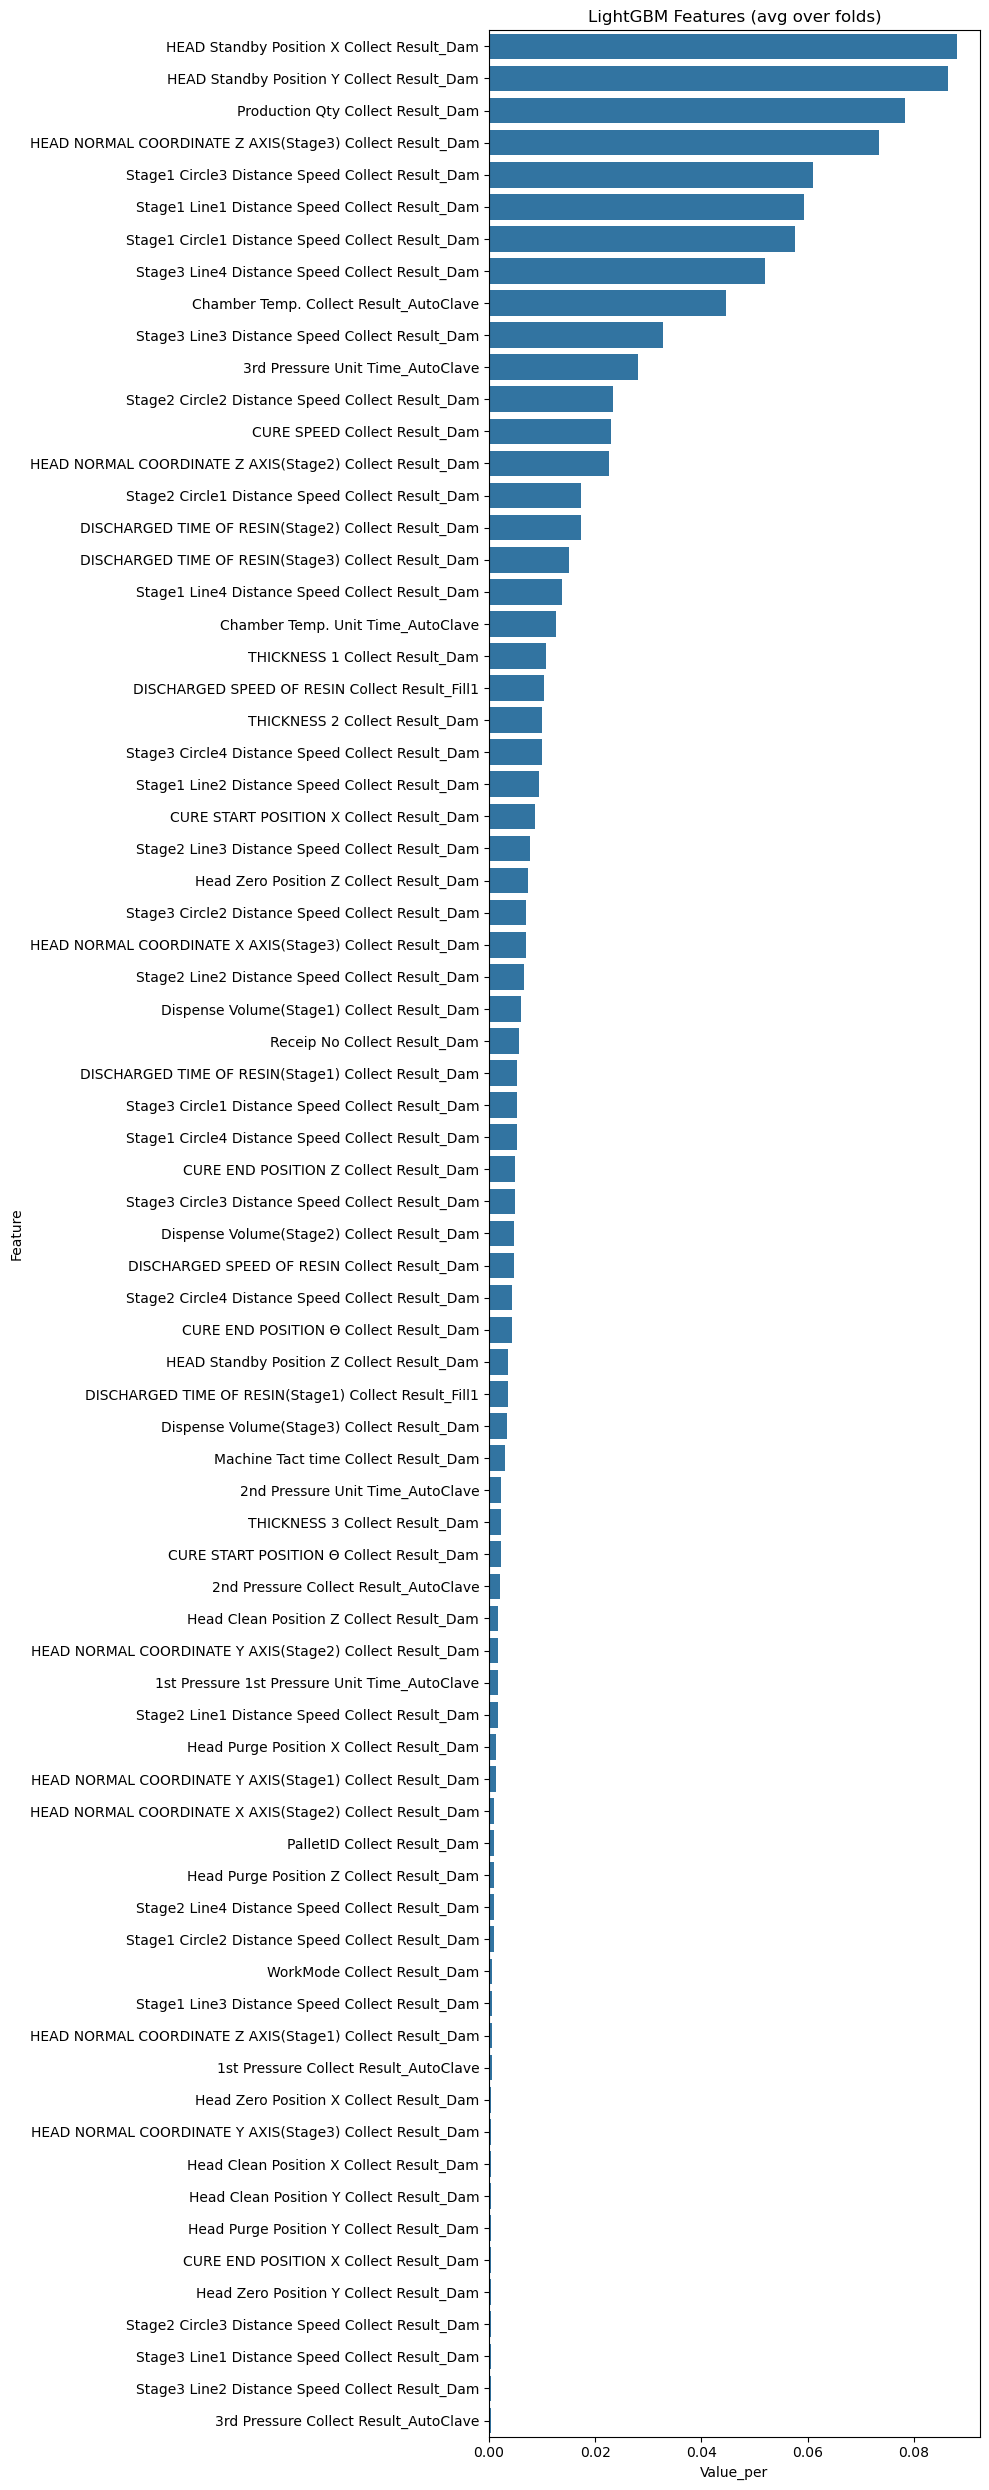

In [84]:
# feature importance 정렬 후  시각화
feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, features)), columns=['Value','Feature'])
feature_imp['Value_per'] = feature_imp['Value'] / feature_imp['Value'].sum()

plt.figure(figsize=(10, 25))
sns.barplot(x="Value_per", y="Feature", data=feature_imp.sort_values(by="Value_per", ascending=False))
plt.title('LightGBM Features (avg over folds)')
plt.tight_layout()
plt.show()

In [88]:
zero_effect_col = feature_imp[feature_imp['Value'] <= 3]['Feature'].values
zero_effect_col

array(['3rd Pressure Collect Result_AutoClave',
       'CURE END POSITION X Collect Result_Dam',
       'HEAD NORMAL COORDINATE Y AXIS(Stage3) Collect Result_Dam',
       'Head Clean Position X Collect Result_Dam',
       'Head Clean Position Y Collect Result_Dam',
       'Head Purge Position Y Collect Result_Dam',
       'Head Zero Position X Collect Result_Dam',
       'Head Zero Position Y Collect Result_Dam',
       'Stage2 Circle3 Distance Speed Collect Result_Dam',
       'Stage3 Line1 Distance Speed Collect Result_Dam',
       'Stage3 Line2 Distance Speed Collect Result_Dam',
       '1st Pressure Collect Result_AutoClave',
       'HEAD NORMAL COORDINATE Z AXIS(Stage1) Collect Result_Dam',
       'Stage1 Line3 Distance Speed Collect Result_Dam',
       'WorkMode Collect Result_Dam',
       'HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Dam',
       'Head Purge Position Z Collect Result_Dam',
       'PalletID Collect Result_Dam',
       'Stage1 Circle2 Distance Speed Collec

In [89]:
len(zero_effect_col)

20

## 변수 영향이 없는 변수 제거 후 다시 진행

In [90]:
# features에서 zero_effect_col 제거
features = [col for col in X_under.columns if col not in zero_effect_col]
len(features)

63

In [91]:
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from collections import Counter

# 예제 데이터 생성

# 원본 데이터 클래스 비율
print_stats(df_train)

X, y = df_train.drop(columns=["target"]), df_train["target"]
X = X[features]

# Random Oversampling
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_ros, y_ros = ros.fit_resample(X, y)
print("Random Oversampling 클래스 비율:", Counter(y_ros))

# SMOTETomek
smote = SMOTE(random_state=RANDOM_STATE)
X_smote, y_smote = smote.fit_resample(X, y)
print("SMOTE 클래스 비율:", Counter(y_smote))

# SMOTETomek
smote_tomek = SMOTETomek(random_state=RANDOM_STATE)
X_smote_tomek, y_smote_tomek = smote_tomek.fit_resample(X, y)
print("SMOTETomek 클래스 비율:", Counter(y_smote_tomek))

# SMOTEENN - 오래 걸림..
smote_enn = SMOTEENN(random_state=RANDOM_STATE)
X_smote_enn, y_smote_enn = smote_enn.fit_resample(X, y)
print("SMOTEENN 클래스 비율:", Counter(y_smote_enn))


  Total: Normal: 26709, AbNormal: 1645 ratio: 0.0580165056076744
Random Oversampling 클래스 비율: Counter({0: 26709, 1: 26709})
SMOTE 클래스 비율: Counter({0: 26709, 1: 26709})
SMOTETomek 클래스 비율: Counter({0: 25812, 1: 25812})
SMOTEENN 클래스 비율: Counter({1: 21956, 0: 16972})


In [92]:
normal_ratio = 3.0
# 전체 데이터에서 Normal과 AbNormal 분리
df_normal = df_train[df_train["target"] == 0]
df_abnormal = df_train[df_train["target"] == 1]

num_normal = len(df_normal)
num_abnormal = len(df_abnormal)
print(f"  Total: Normal: {num_normal}, AbNormal: {num_abnormal}")

df_normal = df_normal.sample(n=int(num_abnormal * normal_ratio), replace=False, random_state=RANDOM_STATE)
df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
X_under, y_under = df_concat.drop(columns=["target"]), df_concat["target"]
# 컬럼 선택
X_under = X_under[features]
print("언더샘플링 후 클래스 비율:", Counter(y_under))

  Total: Normal: 26709, AbNormal: 1645
언더샘플링 후 클래스 비율: Counter({0: 4935, 1: 1645})


In [93]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cat

rf = RandomForestClassifier(random_state=RANDOM_STATE)
xgb = xgb.XGBClassifier(random_state=RANDOM_STATE)
lgbm = lgb.LGBMClassifier(random_state=RANDOM_STATE)
cat = cat.CatBoostClassifier(random_state=RANDOM_STATE)

In [94]:
val_x = df_val[features]
val_y = df_val["target"]
val_x.shape, val_y.shape, val_y.value_counts()

((12152, 63),
 (12152,),
 target
 0    11447
 1      705
 Name: count, dtype: int64)

In [95]:
result_df = pd.DataFrame(columns=["sampling", "model", "f1", "precision", "recall", "accuracy"])

for sample_tech in tqdm(["ros", "smote", "smote_tomek", "smote_enn", "under"]):
    train_x = globals()[f"X_{sample_tech}"]
    train_y = globals()[f"y_{sample_tech}"]
    for model in [rf, xgb, lgbm]:
        model.fit(train_x, train_y)
        y_pred = model.predict(val_x)
        f1 = f1_score(val_y, y_pred)
        precision = precision_score(val_y, y_pred)
        recall = recall_score(val_y, y_pred)
        accuracy = accuracy_score(val_y, y_pred)
        result_df.loc[len(result_df), :] = [sample_tech, model.__class__.__name__, f1, precision, recall, accuracy]
    del train_x, train_y
result_df

  0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 26709, number of negative: 26709
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005559 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2976
[LightGBM] [Info] Number of data points in the train set: 53418, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


 20%|██        | 1/5 [00:06<00:25,  6.27s/it]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 26709, number of negative: 26709
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005878 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11947
[LightGBM] [Info] Number of data points in the train set: 53418, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


 40%|████      | 2/5 [00:14<00:21,  7.19s/it]

...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 21956, number of negative: 16972
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11933
[LightGBM] [Info] Number of data points in the train set: 38928, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.564016 -> initscore=0.257476
[LightGBM] [Info] Start training from score 0.257476


 80%|████████  | 4/5 [00:27<00:06,  6.80s/it]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1645, number of negative: 4935
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001180 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2757
[LightGBM] [Info] Number of data points in the train set: 6580, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.250000 -> initscore=-1.098612
[LightGBM] [Info] Start training from score -1.098612


100%|██████████| 5/5 [00:29<00:00,  5.81s/it]


,sampling,model,f1,precision,recall,accuracy
0,ros,RandomForestClassifier,0.095718,0.426966,0.053901,0.940915
1,ros,XGBClassifier,0.159615,0.105359,0.329078,0.798963
2,ros,LGBMClassifier,0.171768,0.108647,0.409929,0.770655
3,smote,RandomForestClassifier,0.083439,0.383721,0.046809,0.940339
4,smote,XGBClassifier,0.079385,0.407895,0.043972,0.940833
5,smote,LGBMClassifier,0.058667,0.488889,0.031206,0.941903
6,smote_tomek,RandomForestClassifier,0.096774,0.386139,0.055319,0.940092
7,smote_tomek,XGBClassifier,0.093909,0.445783,0.052482,0.941244
8,smote_tomek,LGBMClassifier,0.074766,0.636364,0.039716,0.942972
9,smote_enn,RandomForestClassifier,0.115079,0.191419,0.08227,0.926596


In [96]:
model = lgb.LGBMClassifier(random_state=RANDOM_STATE)
model.fit(X_ros, y_ros)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 26709, number of negative: 26709
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007021 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2976
[LightGBM] [Info] Number of data points in the train set: 53418, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(random_state=736665)

In [97]:
df_test_x = test_data[features]

In [62]:
test_pred = model.predict(df_test_x)
test_pred

array([0, 0, 1, ..., 0, 0, 0])

### 제출 파일 작성
파일 제출 전에 이름, 컬럼명, ID 있는지 잘 확인후 제출!

In [64]:
# 제출 데이터 읽어오기 (df_test는 전처리된 데이터가 저장됨)
df_sub = pd.read_csv(os.path.join(ROOT_DIR, "submission.csv"))
df_sub["target"] = test_pred
df_sub.loc[df_sub["target"] == 0, 'target'] = "Normal"
df_sub.loc[df_sub["target"] == 1, 'target'] = "AbNormal"
# 제출 파일 저장
df_sub.to_csv("submission.csv", index=False)